# 3. EDA - features

In [25]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6401 entries, 0 to 6400
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   cod_mun                      6401 non-null   object  
 1   año                          6401 non-null   object  
 2   NOMBRE                       6400 non-null   object  
 3   analfabetismo                6400 non-null   float64 
 4   bajo_logro_educativo         6400 non-null   float64 
 5   barreras_primera_infancia    6400 non-null   float64 
 6   barreras_acceso_salud        6400 non-null   float64 
 7   tasa_dependencia             6400 non-null   float64 
 8   hacinamiento_critico         6400 non-null   float64 
 9   inadec_eliminacion_excretas  6400 non-null   float64 
 10  inasistencia_escolar         6400 non-null   float64 
 11  inadec_paredes               6400 non-null   float64 
 12  inadec_pisos                 6400 non-null   float64 
 13  rez

**1. Evolución temporal**

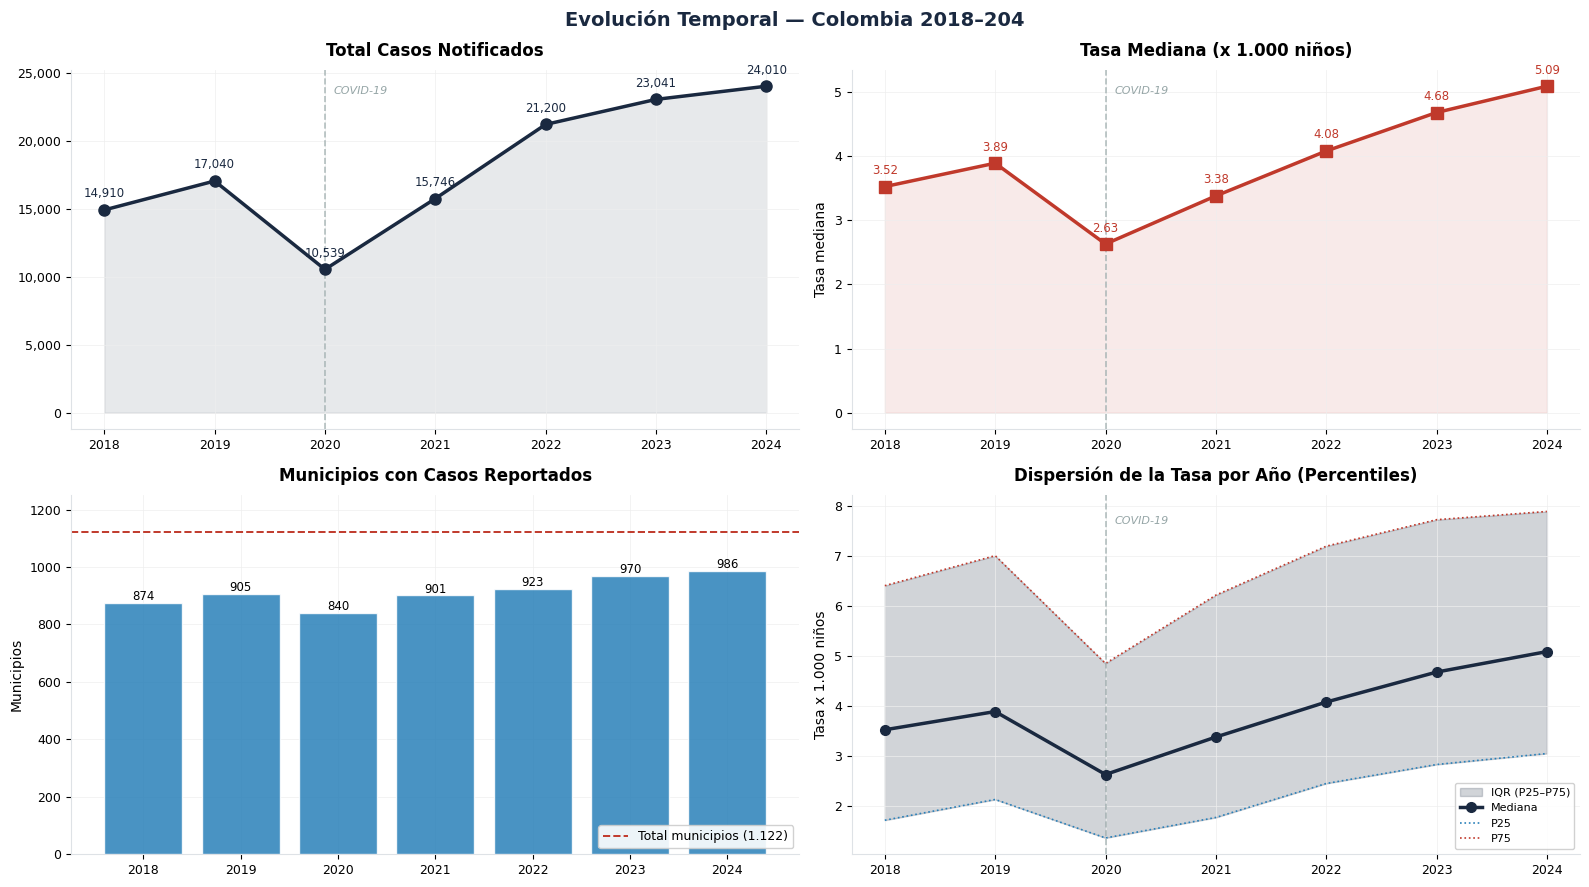

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Evolución Temporal — Colombia 2018–204',
             fontsize=14, fontweight='bold', color=C['primary'])

años = sorted(df_modelo['año'].unique())



# 3.1 Total casos
ca = df_modelo.groupby('año')['casos_totales'].sum()
axes[0,0].plot(ca.index, ca.values, marker='o', lw=2.5,
               color=C['primary'], ms=8, zorder=4)
axes[0,0].fill_between(ca.index, ca.values, alpha=0.1, color=C['primary'])
anotar(axes[0,0], ca.index, ca.values, '{:,.0f}')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0,0].set_title('Total Casos Notificados'); axes[0,0].set_xticks(años)
covid_line(axes[0,0])

# 3.2 Tasa mediana
ta = df_modelo.groupby('año')['tasa_x1000'].median()
axes[0,1].plot(ta.index, ta.values, marker='s', lw=2.5,
               color=C['alto'], ms=8, zorder=4)
axes[0,1].fill_between(ta.index, ta.values, alpha=0.1, color=C['alto'])
anotar(axes[0,1], ta.index, ta.values, '{:.2f}', C['alto'])
axes[0,1].set_title('Tasa Mediana (x 1.000 niños)')
axes[0,1].set_ylabel('Tasa mediana'); axes[0,1].set_xticks(años)
covid_line(axes[0,1])

# 3.3 Municipios reportantes
ma = df_modelo.groupby('año')['cod_mun'].nunique()
bars = axes[1,0].bar(ma.index, ma.values, color=C['accent'],
                     alpha=0.85, edgecolor='white', zorder=3)
axes[1,0].axhline(1122, color=C['alto'], ls='--', lw=1.4,
                  label='Total municipios (1.122)')
axes[1,0].set_title('Municipios con Casos Reportados')
axes[1,0].set_ylabel('Municipios'); axes[1,0].set_xticks(años)
axes[1,0].legend(loc='lower right'); axes[1,0].set_ylim(0, 1250)
for bar in bars:
    h = bar.get_height()
    axes[1,0].text(bar.get_x()+bar.get_width()/2, h+10,
                   f'{int(h):,}', ha='center', fontsize=8.5)

# 3.4 Evolución tasa por cuartil
q_año = df_modelo.groupby('año')['tasa_x1000'].quantile([0.25, 0.5, 0.75]).unstack()
axes[1,1].fill_between(q_año.index, q_año[0.25], q_año[0.75],
                        alpha=0.2, color=C['primary'], label='IQR (P25–P75)')
axes[1,1].plot(q_año.index, q_año[0.50], marker='o', lw=2.5,
               color=C['primary'], ms=7, label='Mediana', zorder=4)
axes[1,1].plot(q_año.index, q_año[0.25], ls=':', lw=1.2,
               color=C['accent'], label='P25')
axes[1,1].plot(q_año.index, q_año[0.75], ls=':', lw=1.2,
               color=C['alto'], label='P75')
axes[1,1].set_title('Dispersión de la Tasa por Año (Percentiles)')
axes[1,1].set_ylabel('Tasa x 1.000 niños'); axes[1,1].set_xticks(años)
axes[1,1].legend(fontsize=8)
covid_line(axes[1,1])

plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'eda_01_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


* Caída atípica en 2020 (10.539 casos) asociada al subregistro durante el confinamiento por COVID-19.
* Repunte continuo post-pandemia alcanzando el pico en 2024 (24.010 casos / 986 municipios reportantes).
* La tasa mediana aumentó de 2.63 a 5.09 por mil niños entre 2020 y 2024.
* La dispersión de la tasa (P25-P75) se amplió, evidenciando una mayor brecha y desigualdad entre territorios

**2. Privaciones a nivel nacional**

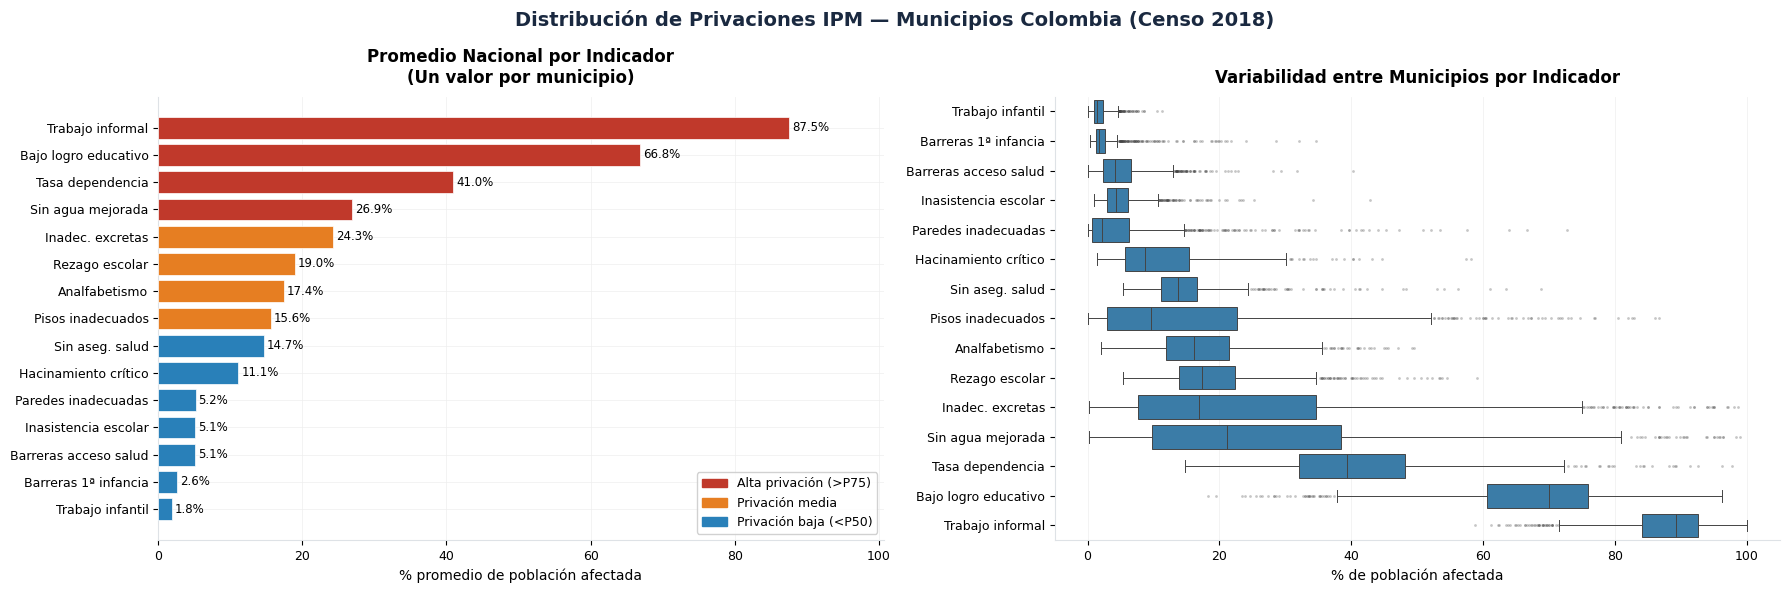

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribución de Privaciones IPM — Municipios Colombia (Censo 2018)',
             fontsize=14, fontweight='bold', color=C['primary'])

medias = df_modelo.groupby('cod_mun')[VARS_IPM].first().mean().rename(ETIQ).sort_values()

# 4.1 Barras con media nacional
umbral_alto = medias.quantile(0.75)
umbral_med  = medias.quantile(0.50)
cols_bar = [C['alto'] if v >= umbral_alto else
            C['medio'] if v >= umbral_med else C['accent']
            for v in medias.values]
bars = axes[0].barh(medias.index, medias.values, color=cols_bar,
                    edgecolor='white', lw=0.5, zorder=3)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.4, bar.get_y()+bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=8.5)
axes[0].set_xlim(0, medias.max() * 1.15)
axes[0].set_title('Promedio Nacional por Indicador\n(Un valor por municipio)')
axes[0].set_xlabel('% promedio de población afectada')
leyenda = [mpatches.Patch(color=C['alto'],  label='Alta privación (>P75)'),
           mpatches.Patch(color=C['medio'], label='Privación media'),
           mpatches.Patch(color=C['accent'],label='Privación baja (<P50)')]
axes[0].legend(handles=leyenda, loc='lower right')

# 4.2 Boxplot distribución entre municipios
df_ipm_mun = df_modelo.groupby('cod_mun')[VARS_IPM].first().rename(columns=ETIQ)
df_melt_ipm = df_ipm_mun.melt(var_name='Indicador', value_name='Valor')
orden_box = medias.rename(index={v: k for k, v in ETIQ.items()}).sort_values().rename(index=ETIQ).index.tolist()
sns.boxplot(data=df_melt_ipm, y='Indicador', x='Valor',
            order=orden_box, color=C['accent'],
            linewidth=0.7, flierprops=dict(marker='.', ms=2, alpha=0.3),
            ax=axes[1])
axes[1].set_title('Variabilidad entre Municipios por Indicador')
axes[1].set_xlabel('% de población afectada'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(RUTA_IMAGENES /'eda_02_privaciones_ipm.png', dpi=150, bbox_inches='tight')
plt.show()


* Trabajo informal (87.5%) y bajo logro educativo (66.8%) presentan la mayor
prevalencia media
* Barreras a 1ª infancia (2.6%) y trabajo infantil (1.8%) muestran los menores niveles de afectación.
* Brechas territoriales profundas: Indicadores de infraestructura como agua potable e higiene/excretas varían entre el 0% y cerca del 100%.
* La amplia dispersión intermunicipal en saneamiento básico y educación proporciona la variabilidad necesaria para clasificar el riesgo.

**3. Correlaciones entre variables**


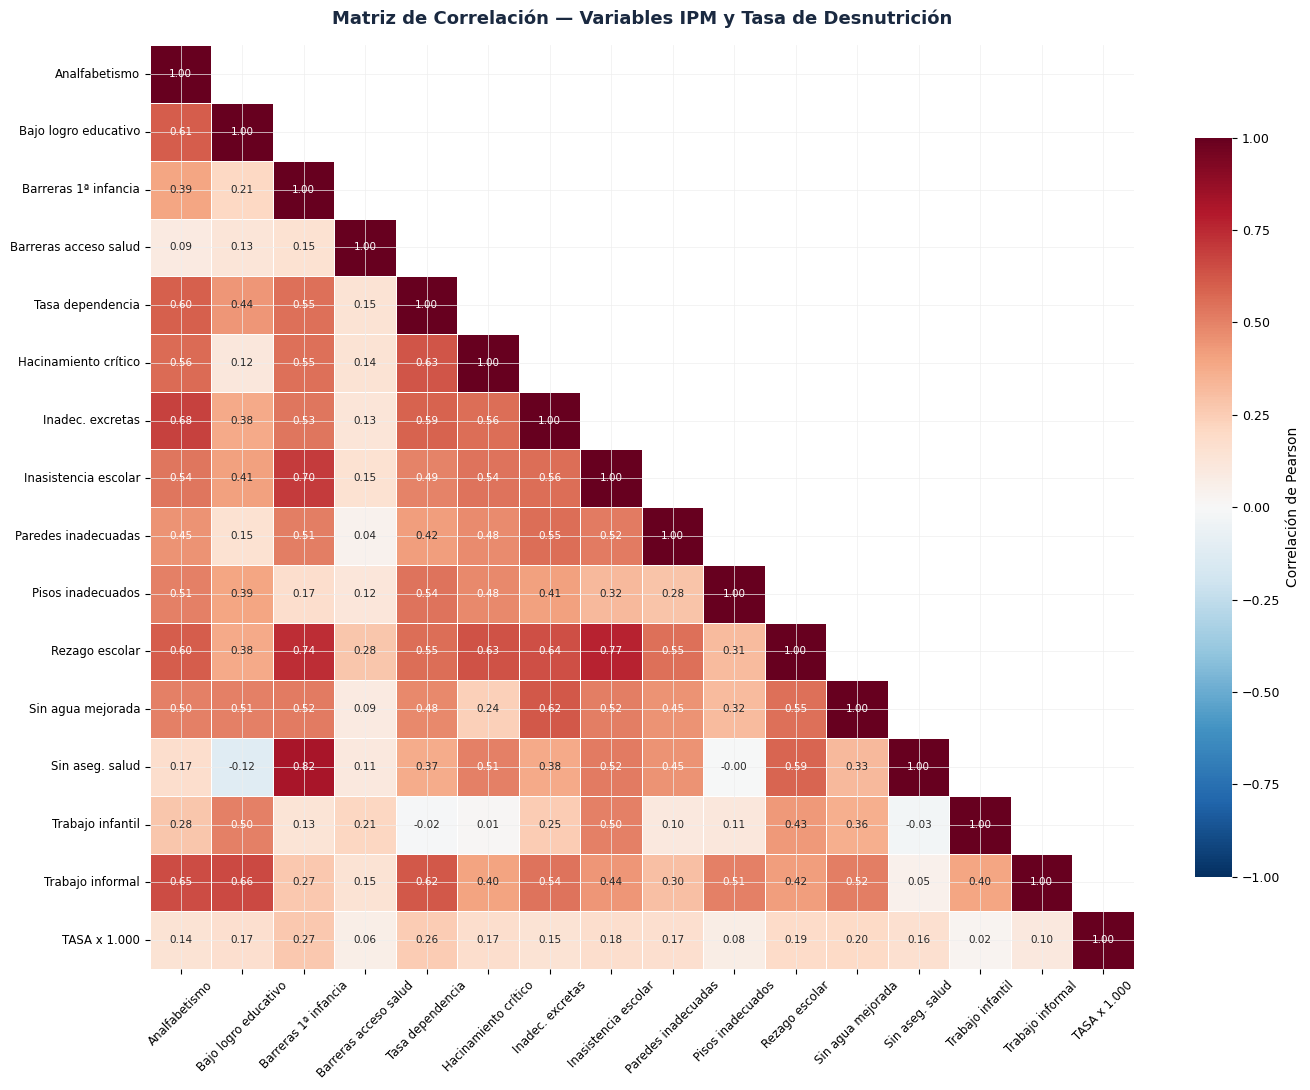

In [28]:
fig, ax = plt.subplots(figsize=(14, 11))

corr_matrix = df_modelo[VARS_IPM + ['tasa_x1000']].corr()
cols_ordenadas = VARS_IPM + ['tasa_x1000']
corr_plot = corr_matrix.loc[cols_ordenadas, cols_ordenadas].rename(
    index=ETIQ, columns=ETIQ)
corr_plot = corr_plot.rename(index={'tasa_x1000': 'TASA x 1.000'},
                              columns={'tasa_x1000': 'TASA x 1.000'})

mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)
sns.heatmap(
    corr_plot, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'}
)
ax.set_title('Matriz de Correlación — Variables IPM y Tasa de Desnutrición',
             fontsize=13, fontweight='bold', color=C['primary'], pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8.5)
ax.tick_params(axis='y', rotation=0,  labelsize=8.5)

plt.tight_layout()
plt.savefig(RUTA_IMAGENES /'eda_04_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()


* Correlaciones directas con el target están lideradas por Barreras 1ª infancia (0.27), Tasa de dependencia (0.26), Sin agua mejorada (0.20) y Rezago escolar (0.19).
* Las asociaciones lineales moderadas con la TASA reafirman que la vulnerabilidad nutricional es un fenómeno no lineal y complejo.
* Elevadas correlaciones inter-variables, como Sin aseg. salud vs Barreras 1ª infancia (0.82) e Inasistencia vs Rezago escolar (0.77).
* Los modelos basados en árboles de decisión (RF/XGBoost) absorben eficientemente la colinealidad sin distorsionar su capacidad predictiva.

4. Distribucción de cada variable

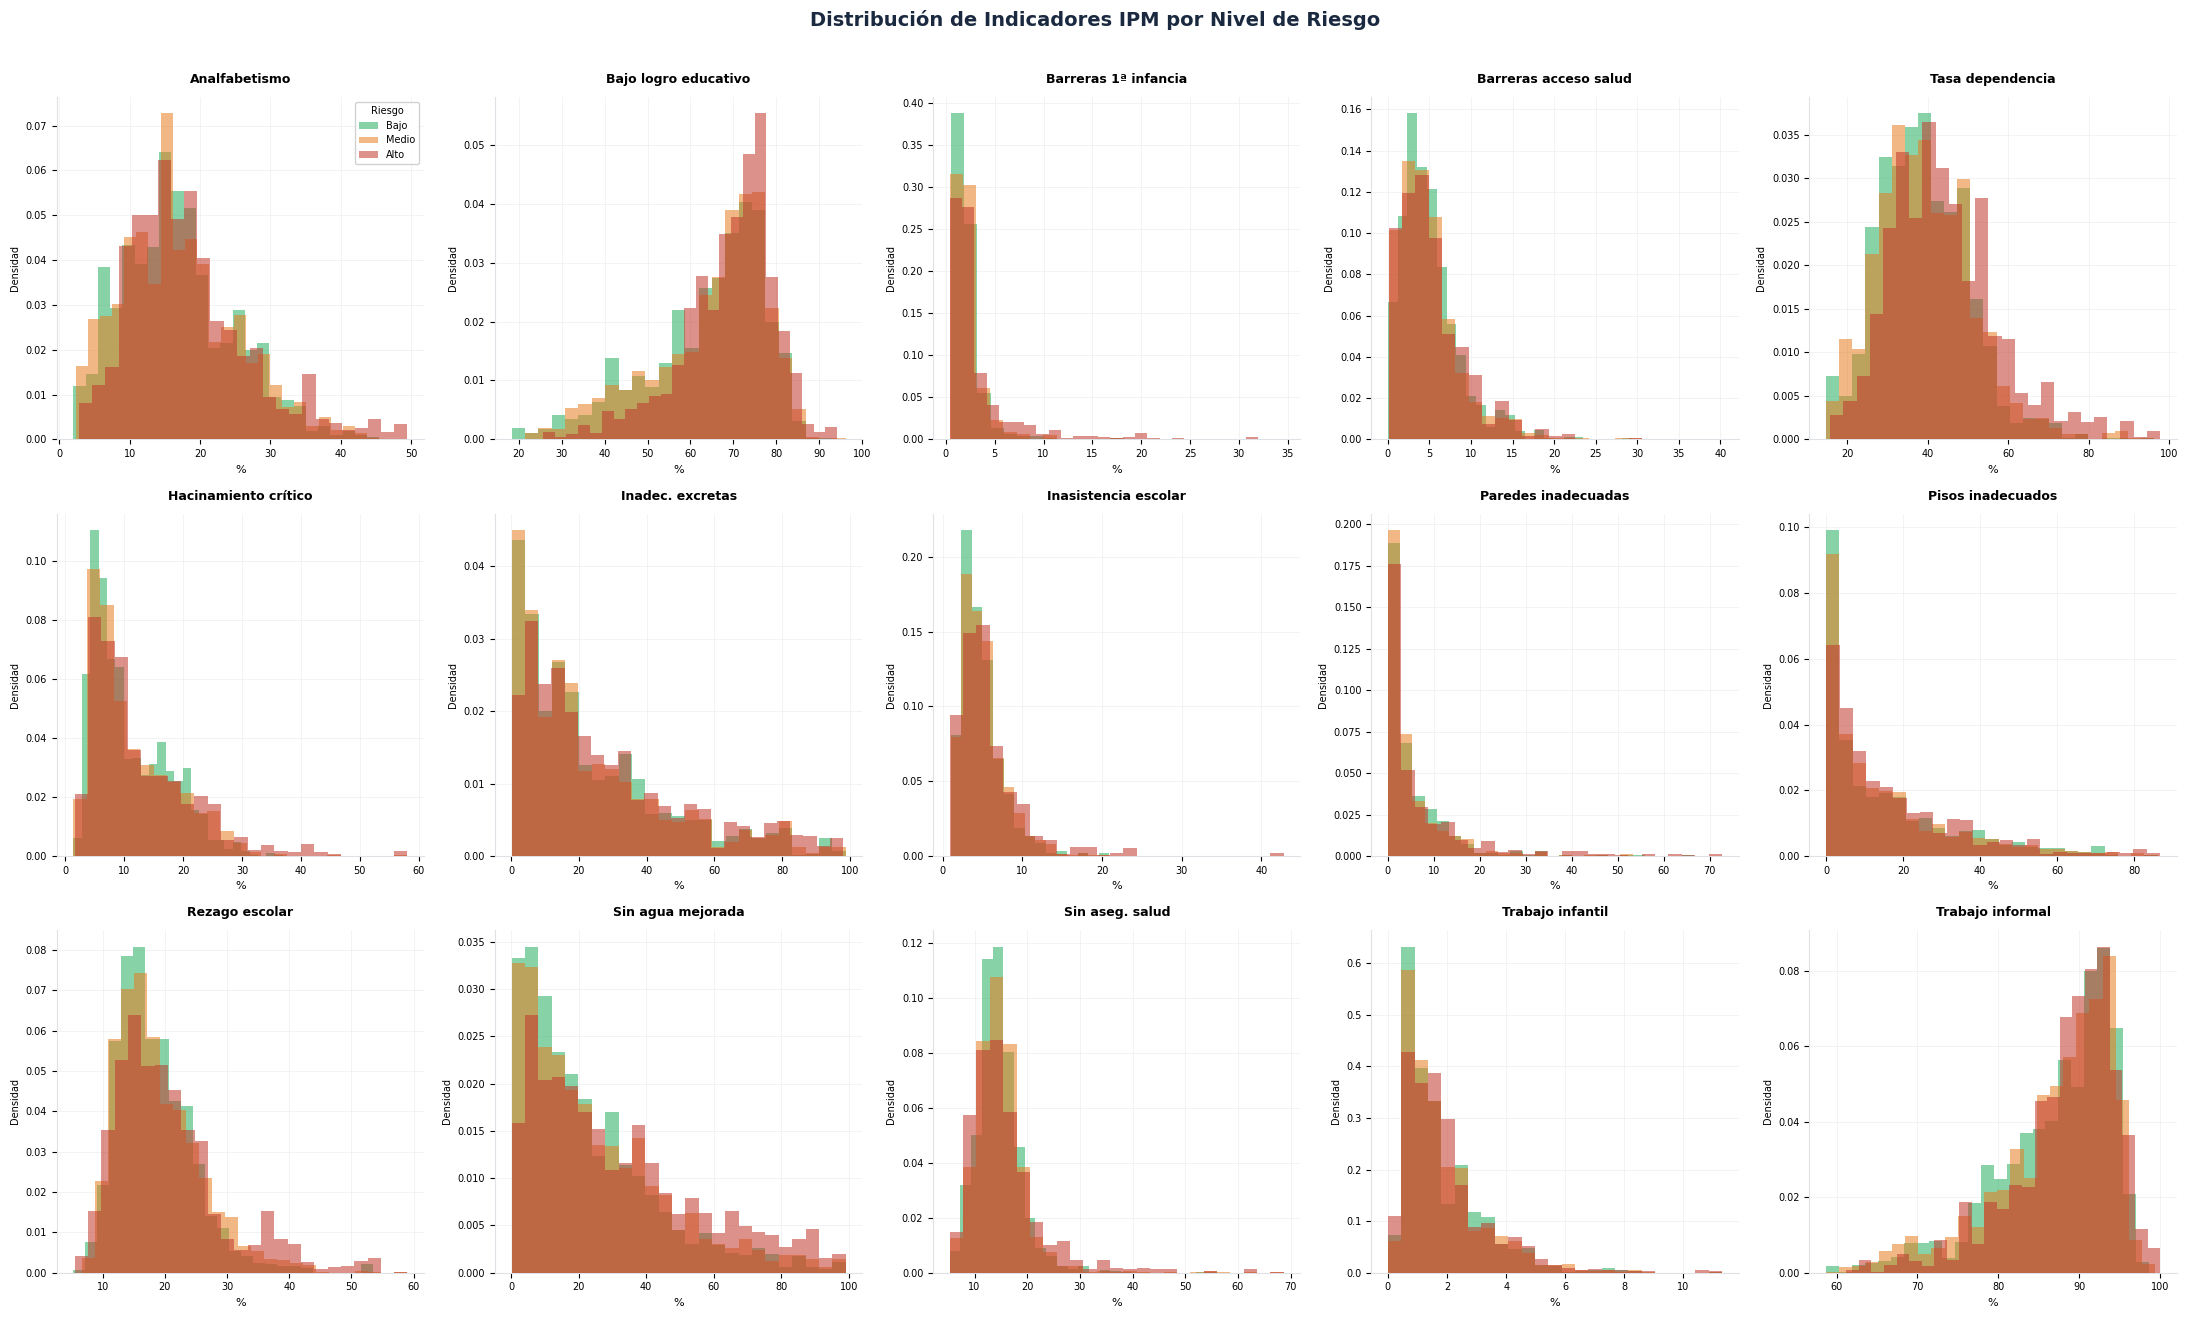

In [29]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
fig.suptitle('Distribución de Indicadores IPM por Nivel de Riesgo',
             fontsize=14, fontweight='bold', color=C['primary'], y=1.01)
axes_flat = axes.flatten()

for i, (col, etiq) in enumerate(ETIQ.items()):
    ax = axes_flat[i]
    for cat in ORDEN:
        vals = df_modelo[df_modelo['riesgo'] == cat][col].dropna()
        ax.hist(vals, bins=25, alpha=0.55, color=C_RISK[cat],
                label=cat.capitalize(), zorder=3, density=True)
    ax.set_title(etiq, fontsize=9, fontweight='bold')
    ax.set_xlabel('%', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(title='Riesgo', fontsize=7, title_fontsize=7)

plt.tight_layout()
plt.savefig(RUTA_IMAGENES /'eda_05_distribuciones_ipm.png', dpi=150, bbox_inches='tight')
plt.show()


*En indicadores clave (Sin agua mejorada, Inadec. excretas, Rezago escolar y Bajo logro educativo), la clase de riesgo 'Alto' muestra mayor densidad en valores elevados de privación.
* Gran parte de las distribuciones se superponen entre categorías (Bajo, Medio y Alto), evidenciando que un análisis univariate resulta insuficiente para separar las clases.
* Indicadores como Barreras 1ª infancia, Trabajo infantil y Paredes inadecuadas presentan fuerte asimetría positiva (cola a la derecha).
* El marcado solapamiento demuestra que el riesgo nutricional es producto de la interacción multivariable no lineal, requiriendo modelos de árboles de decisión para su adecuada clasificación.

**5. Analísis de los registros**

  ANÁLISIS DE SUBREGISTRO — SIVIGILA
  2018   874 muns  (78%)  █████████████████████████░░░░░░░░
  2019   905 muns  (81%)  ██████████████████████████░░░░░░░
  2020   840 muns  (75%)  ████████████████████████░░░░░░░░░
  2021   901 muns  (80%)  ██████████████████████████░░░░░░░
  2022   923 muns  (82%)  ███████████████████████████░░░░░░
  2023   970 muns  (86%)  ████████████████████████████░░░░░
  2024   986 muns  (88%)  █████████████████████████████░░░░

  ⚠️ 136 municipios sin registro en ningún año
     → Probable subregistro (no ausencia real de desnutrición)


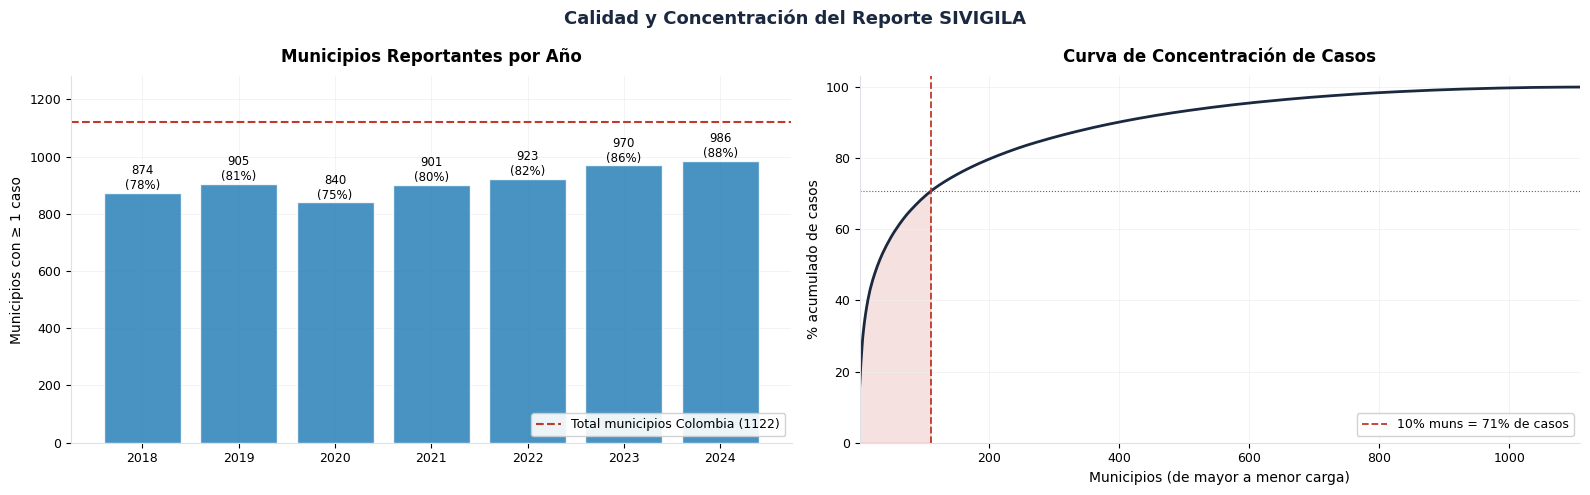


  📊 71% de los casos están en el 10% de municipios más afectados (110)


In [30]:
TOTAL_MUNS = 1122
muns_año   = df_modelo.groupby('año')['cod_mun'].nunique()

print("=" * 56)
print("  ANÁLISIS DE SUBREGISTRO — SIVIGILA")
print("=" * 56)
for año, n in muns_año.items():
    pct  = n / TOTAL_MUNS * 100
    bar  = '█' * int(pct / 3) + '░' * (33 - int(pct / 3))
    print(f"  {año}  {n:>4} muns  ({pct:.0f}%)  {bar}")

print(f"\n  ⚠️ {TOTAL_MUNS - muns_año.max()} municipios sin registro en ningún año")
print(   "     → Probable subregistro (no ausencia real de desnutrición)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Calidad y Concentración del Reporte SIVIGILA',
             fontsize=13, fontweight='bold', color=C['primary'])

# 9.1 Cobertura por año
bars = axes[0].bar(muns_año.index, muns_año.values,
                   color=C['accent'], alpha=0.85, edgecolor='white', zorder=3)
axes[0].axhline(TOTAL_MUNS, color=C['alto'], ls='--', lw=1.5,
                label=f'Total municipios Colombia ({TOTAL_MUNS})')
axes[0].set_title('Municipios Reportantes por Año')
axes[0].set_ylabel('Municipios con ≥ 1 caso')
axes[0].set_xticks(muns_año.index); axes[0].set_ylim(0, 1280)
axes[0].legend(loc='lower right')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+12,
                 f'{int(h):,}\n({h/TOTAL_MUNS*100:.0f}%)', ha='center', fontsize=8.5)

# 9.2 Curva de concentración de casos
casos_mun = (df_modelo.groupby('cod_mun')['casos_totales']
             .sum().sort_values(ascending=False))
cum_pct   = casos_mun.cumsum() / casos_mun.sum() * 100
n_total   = len(casos_mun)
top10     = int(n_total * 0.10)
pct_top10 = casos_mun.head(top10).sum() / casos_mun.sum() * 100

axes[1].plot(range(1, n_total+1), cum_pct, color=C['primary'], lw=2)
axes[1].fill_between(range(1, top10+1),
                     casos_mun.head(top10).cumsum() / casos_mun.sum() * 100,
                     alpha=0.15, color=C['alto'])
axes[1].axvline(top10, color=C['alto'], ls='--', lw=1.3,
                label=f'10% muns = {pct_top10:.0f}% de casos')
axes[1].axhline(pct_top10, color=C['alto'], ls=':', lw=0.8)
axes[1].set_title('Curva de Concentración de Casos')
axes[1].set_xlabel('Municipios (de mayor a menor carga)')
axes[1].set_ylabel('% acumulado de casos')
axes[1].set_xlim(1, n_total); axes[1].set_ylim(0, 103)
axes[1].legend()

plt.tight_layout()
plt.savefig(RUTA_IMAGENES /'eda_06_subregistro.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  📊 {pct_top10:.0f}% de los casos están en el 10% de municipios más afectados ({top10})")

* La curva acumulada muestra que solo el 10% de los municipios concentra el 71% de la totalidad de los casos notificados en Colombia.
* La alta disparidad justifica una estrategia de priorización territorial, donde la intervención focalizada en pocos municipios genera un impacto masivo en salud pública.

**6. Mapa con la zonas de mayor incidencia**

In [31]:
# 1. Filtrar por el año 2024
df_mapa = df_modelo[df_modelo['año'] == 2024]

# 3. Creas el mapa de coropletas
fig = px.choropleth_mapbox(
    df_mapa,
    geojson=geojson_dane,
    locations='cod_mun',
    featureidkey="properties.mpio_cdpmp",
    color='tasa_x1000',
    color_continuous_scale="Reds",
    mapbox_style="carto-positron",
    zoom=4.5,
    center={"lat": 4.5709, "lon": -74.2973},
    opacity=0.7,
    title="Riesgo de Desnutrición Infantil por Municipio en Colombia (2024)"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

[Salida 'text/html' omitida por tamaño (230.5 MB) — probablemente una visualización interactiva (mapa/HTML). Ver el notebook original TFM_VF.ipynb, celda 62]

*La Guajira, Chocó y regiones de la Orinoquía/Amazonía (como Vichada) registran los niveles más oscuros en la escala (tasas superiores a 50 por cada 1.000 niños).
* La región Andina central exhibe niveles significativamente más bajos de riesgo, contrastando con la alta incidencia en fronteras y zonas costeras/rurales dispersas.
* El riesgo epidemiológico no se distribuye de forma aleatoria, sino que forma clusters regionales continuos de alta vulnerabilidad.